# Training Analysis

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

In [2]:
def get_data(df: pd.DataFrame, start: int, end: int, num_models: int) -> np.ndarray:
    data = [df["value"].iloc[start + i:end:num_models].to_numpy() for i in range(num_models)]
    return np.array(data)

In [3]:
def show_results(path: str):
    df = pd.read_csv(path)

    accuracy = np.mean(get_data(df, 200, 300, 5), axis=0)
    train_loss = np.mean(get_data(df, 100, 200, 5), axis=0)
    val_loss = np.mean(get_data(df, 300, 400, 5), axis=0)
    
    epochs = np.arange(0, 20)

    fig, axes = plt.subplots(1, 2, figsize=(12, 5))

    axes[0].plot(epochs, train_loss, label="Train loss")
    axes[0].plot(epochs, val_loss, label="Val loss")
    axes[0].set_title("Loss Curves")
    axes[0].set_xlabel("Epochs")
    axes[0].set_ylabel("Loss")
    axes[0].legend()
    axes[0].grid(True)

    axes[1].plot(epochs, accuracy)
    axes[1].set_title("Accuracy Curve")
    axes[1].set_xlabel("Epochs")
    axes[1].set_ylabel("Accuracy")
    axes[1].grid(True)

    plt.tight_layout()
    plt.show()

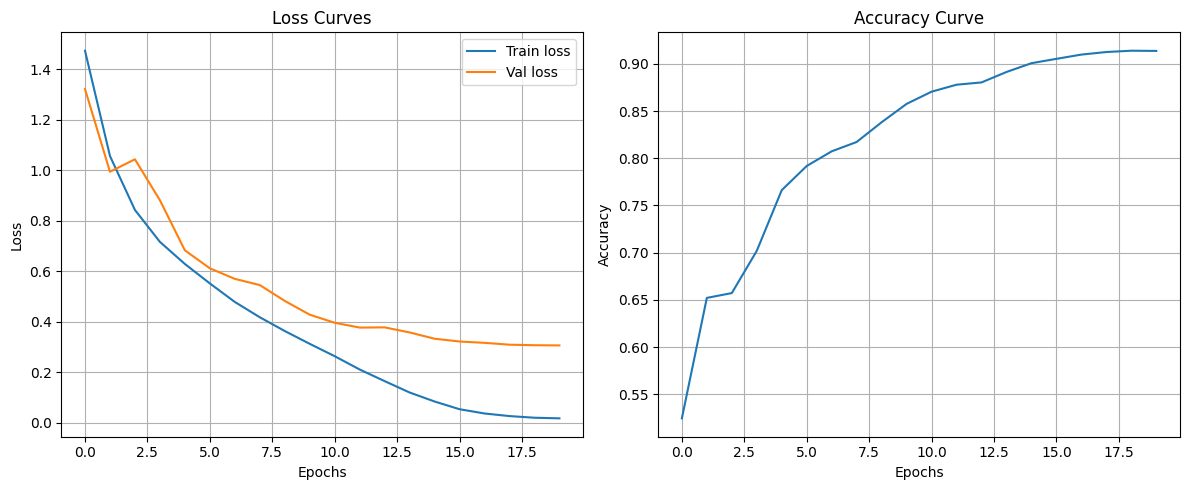

In [4]:
show_results("history/vanilla_history.csv")

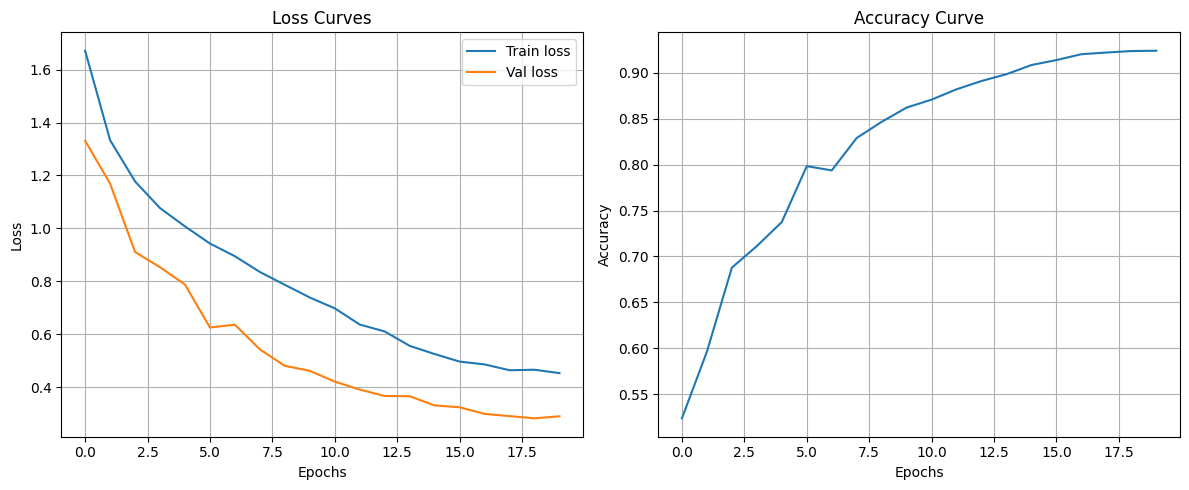

In [5]:
show_results("history/mixup_history.csv")

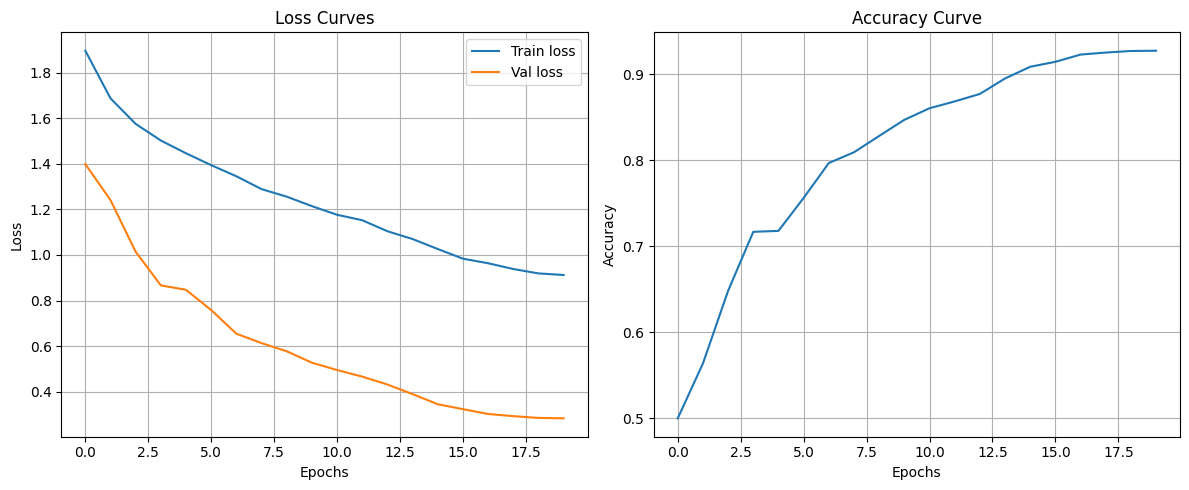

In [6]:
show_results("history/fmix_history.csv")

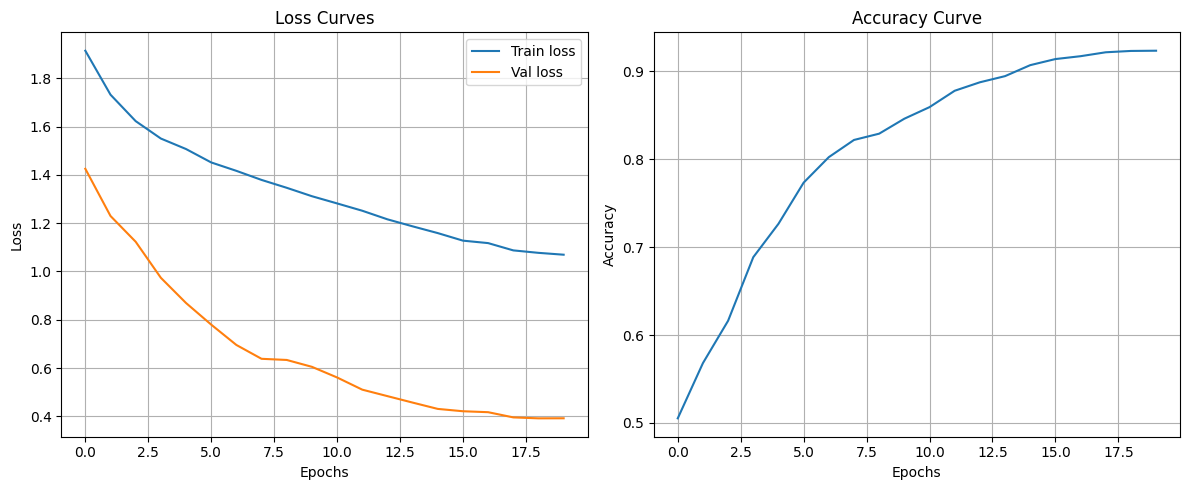

In [7]:
show_results("history/agmix_history.csv")